<a href="https://colab.research.google.com/github/arulperiyannagounder-collab/Training_Hands_on/blob/main/Handling_Missing_values_and_Outliers_Employee_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv('/content/drive/MyDrive/PLACEMENT AI/Dataset/preprocessing_dataset.csv')
dat=data
d1,d2,d3=data.copy(),data.copy(),data.copy()

In [ ]:
data.isnull().sum()

,0
Name,0
Age,1
Gender,1
Salary,1
Department,0


In [ ]:
data.head()


,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,NaN,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT


In [ ]:
data.tail()

,Name,Age,Gender,Salary,Department
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


In [ ]:
data.describe()

,Age,Salary
count,9.000000,9.000000
mean,39.555556,57777.777778
std,30.631320,4521.553322
min,22.000000,50000.000000
25%,27.000000,55000.000000
50%,29.000000,59000.000000
75%,35.000000,61000.000000
max,120.000000,63000.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        10 non-null     object 
 1   Age         9 non-null      float64
 2   Gender      9 non-null      object 
 3   Salary      9 non-null      float64
 4   Department  10 non-null     object 
dtypes: float64(2), object(3)
memory usage: 532.0+ bytes


<Axes: >

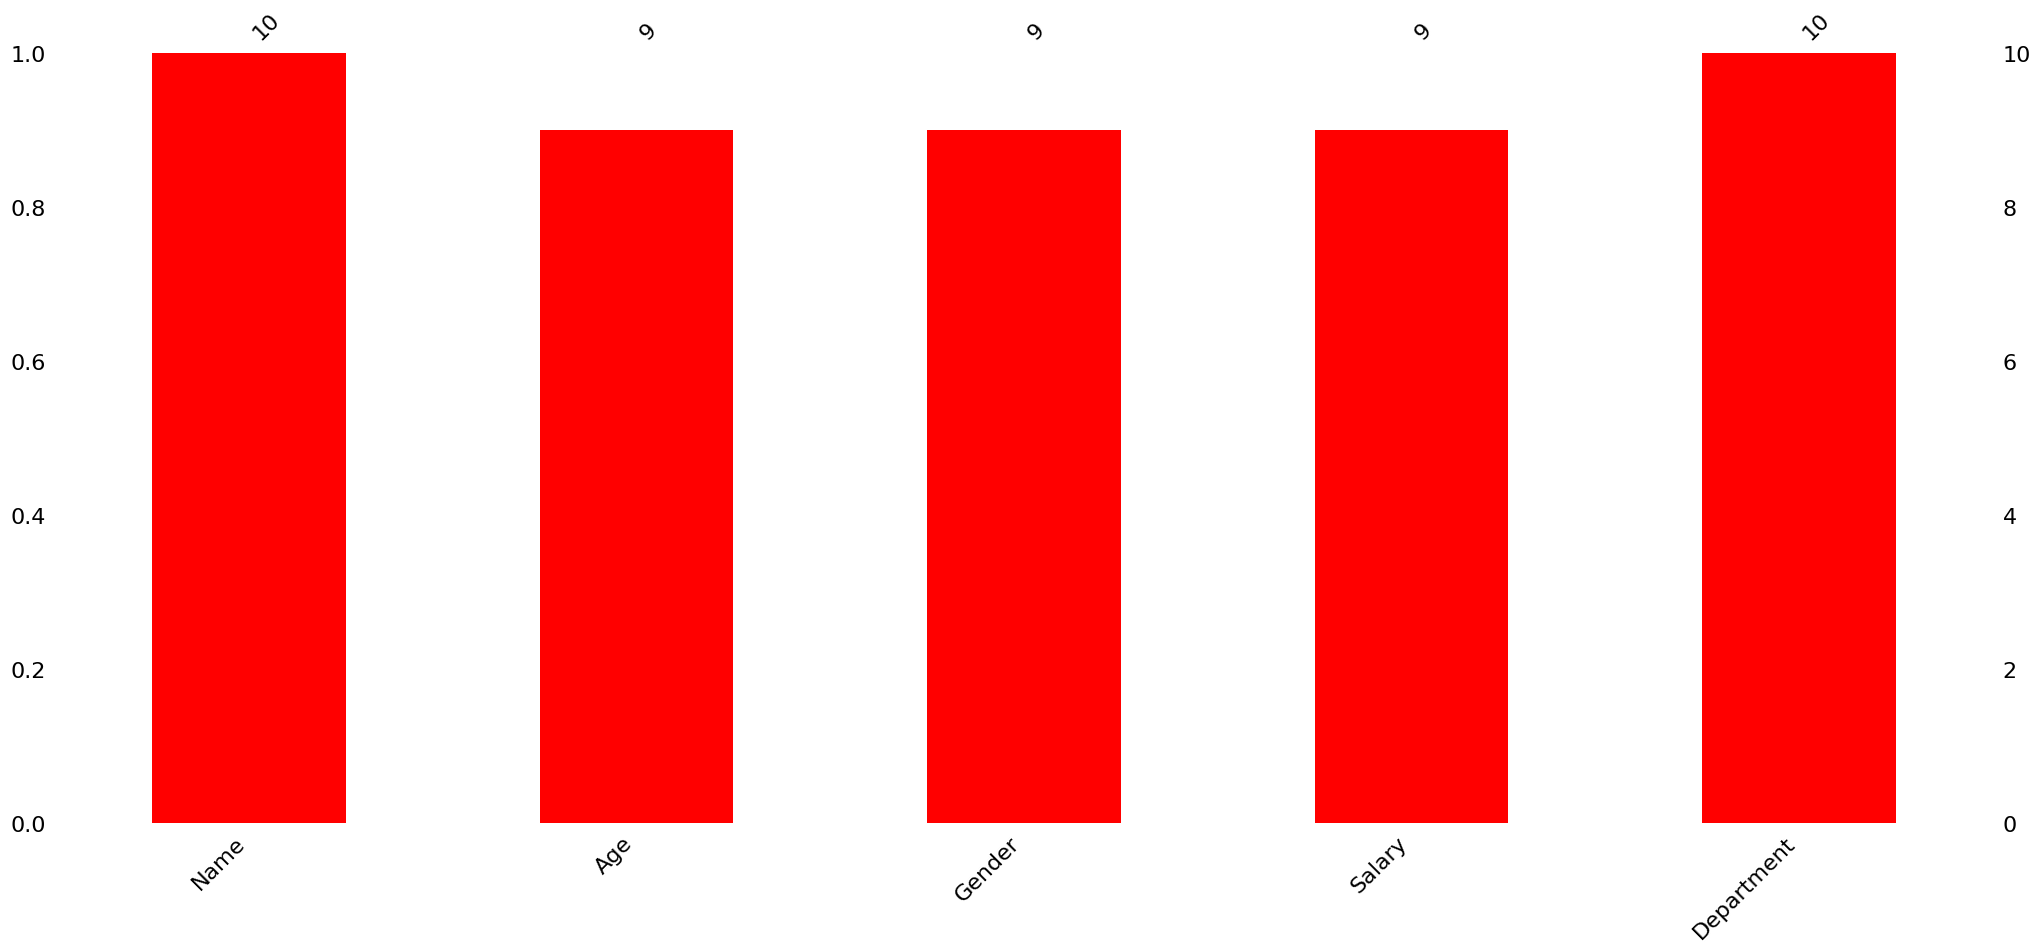

In [ ]:
! pip install missingno
import missingno as msno
msno.bar(data,color='red')

<Axes: >

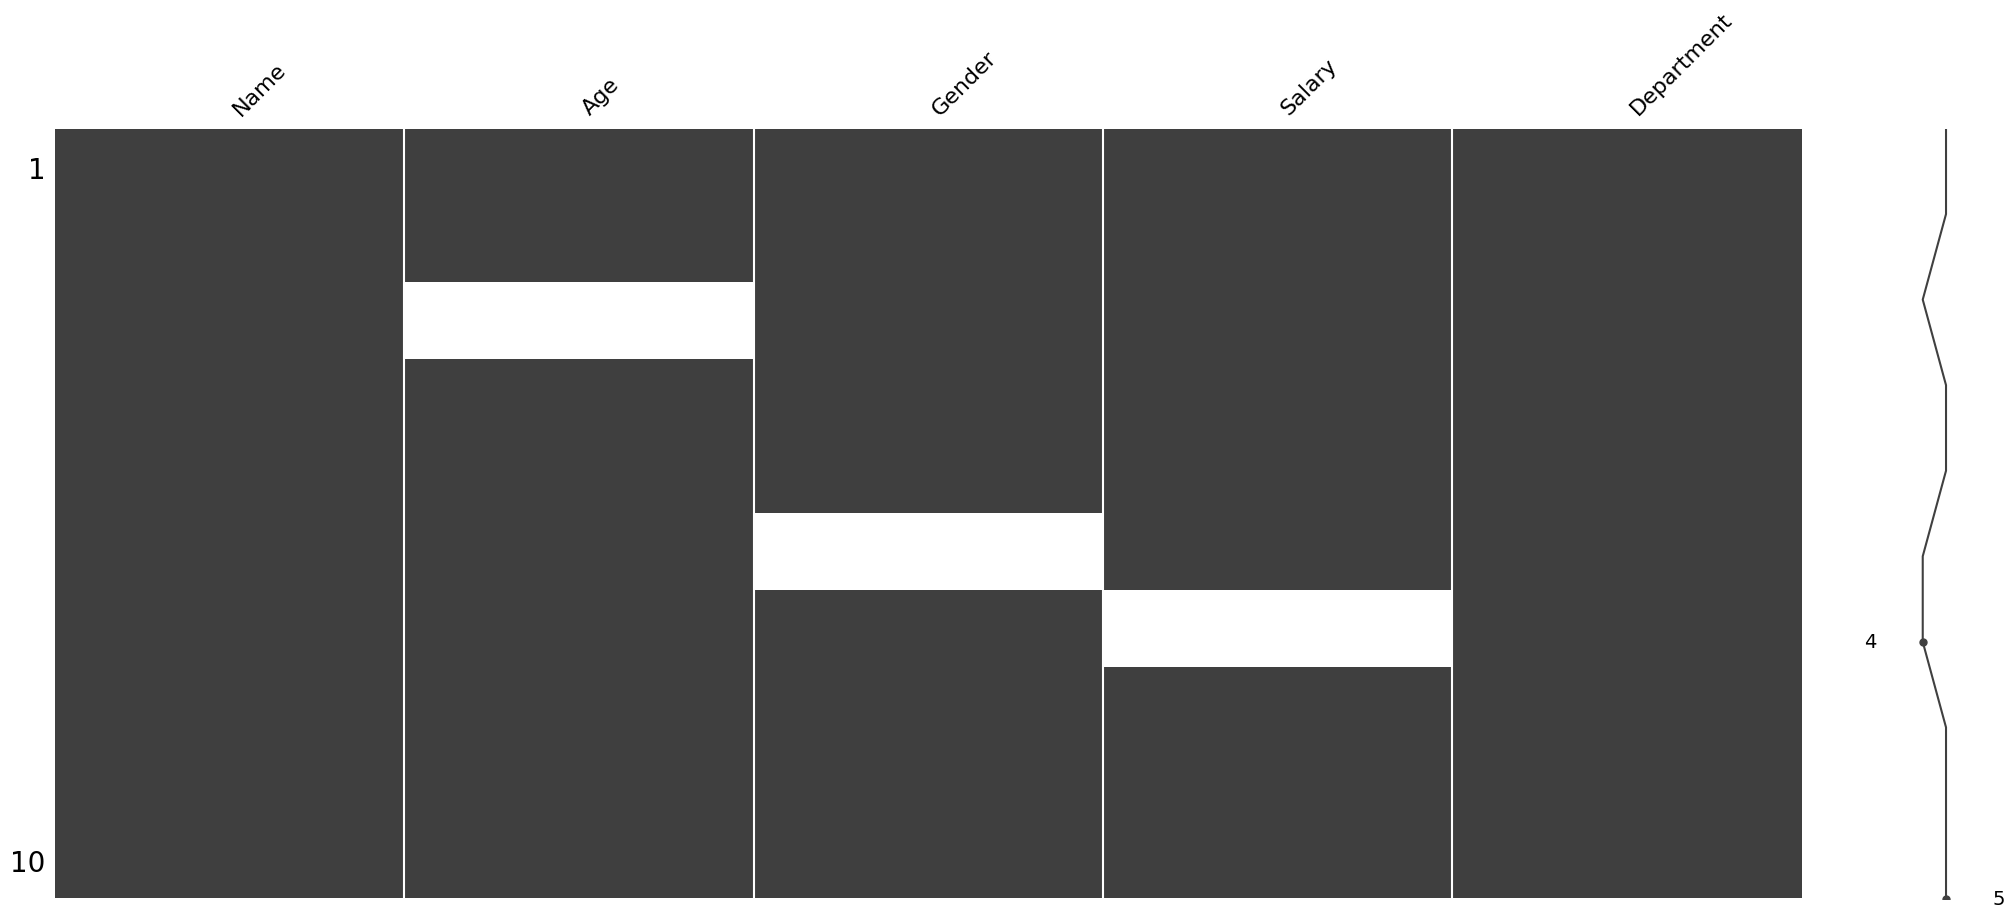

In [ ]:
msno.matrix(data)

<Axes: >

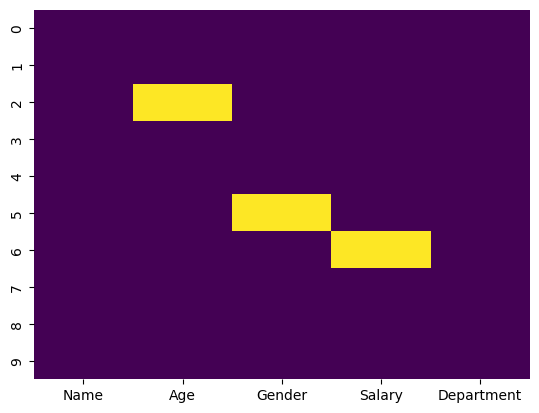

In [ ]:
sns.heatmap(data.isnull(),cbar=False,cmap='viridis')

In [ ]:
data['Age'].fillna(data['Age'].mean(),inplace=True)
data['Salary'].fillna(data['Salary'].mean(),inplace=True)
data['Gender']=data['Gender'].fillna(data['Gender'].mode()[0])

/tmp/ipykernel_12438/868022192.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(),inplace=True)
/tmp/ipykernel_12438/868022192.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [ ]:
data

,Name,Age,Gender,Salary,Department
0,Alice,25.000000,F,50000.000000,HR
1,Bob,30.000000,M,60000.000000,Finance
2,Charlie,39.555556,M,55000.000000,IT
3,David,40.000000,M,58000.000000,HR
4,Eve,22.000000,F,52000.000000,IT
5,Frank,35.000000,M,61000.000000,Finance
6,Grace,120.000000,F,57777.777778,Finance
7,Henry,28.000000,M,59000.000000,HR
8,Ivy,29.000000,F,63000.000000,IT
9,Jack,27.000000,M,62000.000000,Finance


In [ ]:
from sklearn.impute import SimpleImputer
imp=SimpleImputer(strategy='median')
d1['Age']=imp.fit_transform(d1[['Age']])
d1['Salary']=imp.fit_transform(d1[['Salary']])



In [ ]:
imp1=SimpleImputer(strategy='most_frequent')
d1[['Gender']]=imp1.fit_transform(d1[['Gender']])

In [ ]:
d1

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,29.0,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT
5,Frank,35.0,M,61000.0,Finance
6,Grace,120.0,F,59000.0,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


OUTLIER

{'whiskers': [<matplotlib.lines.Line2D at 0x79f650476000>,
 'caps': [<matplotlib.lines.Line2D at 0x79f61754dee0>,
 'boxes': [<matplotlib.lines.Line2D at 0x79f61754d5e0>],
 'medians': [<matplotlib.lines.Line2D at 0x79f6174f4260>],
 'fliers': [<matplotlib.lines.Line2D at 0x79f6174f5460>],
 'means': []}

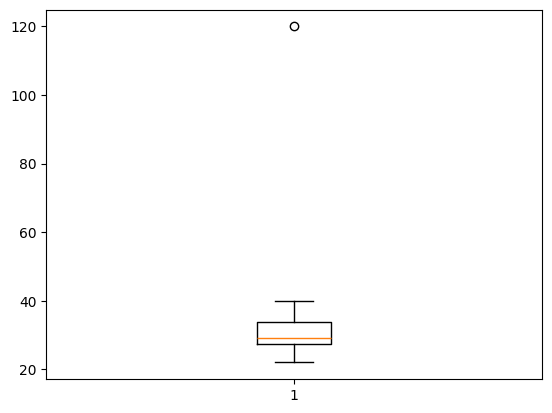

In [ ]:
plt.boxplot(d1['Age'])

<Axes: ylabel='Age'>

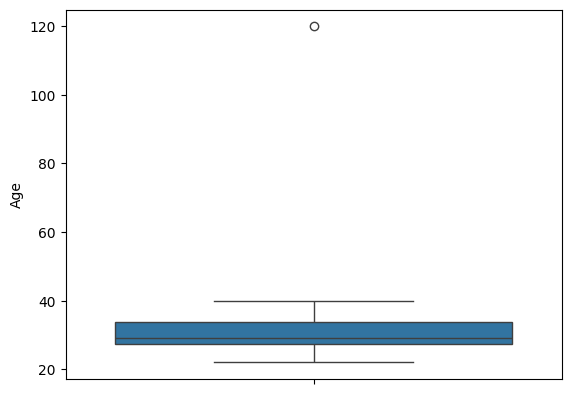

In [ ]:
sns.boxplot(d1['Age'])

In [ ]:
Q1=d1['Age'].quantile(0.25)
Q3=d1['Age'].quantile(0.75)


In [ ]:
IQR=Q3-Q1

up=Q3+1.5*IQR
low=Q1-1.5*IQR
d1[(d1['Age']>up) | (d1['Age']<low)]

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,59000.0,Finance


In [ ]:
from scipy.stats import zscore
zs=zscore(data['Age'])
outlier=data[np.abs(zs)>2]
print(outlier)

    Name    Age Gender        Salary Department
6  Grace  120.0      F  57777.777778    Finance


In [ ]:
from sklearn.ensemble import IsolationForest
iso=IsolationForest(contamination=.1)
data['Outlier']=iso.fit_predict(data[['Age','Salary']])
data[data['Outlier']==-1]

 #-1 is outliers

,Name,Age,Gender,Salary,Department,Outlier
6,Grace,120.0,F,57777.777778,Finance,-1


(array([6., 3., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([ 22. ,  31.8,  41.6,  51.4,  61.2,  71. ,  80.8,  90.6, 100.4,
        110.2, 120. ]),
 <BarContainer object of 10 artists>)

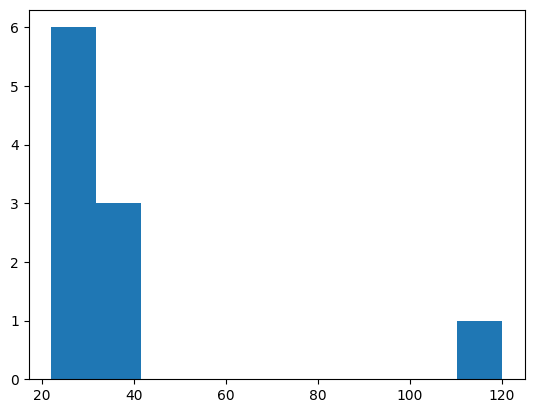

In [ ]:
plt.hist(data['Age'])

# **Winsorization**

In [ ]:
from scipy.stats import mstats
data['Win_Age']=mstats.winsorize(data['Age'],limits=[0.0,0.1])
print(data)

      Name         Age Gender        Salary Department  Outlier    Win_Age
0    Alice   25.000000      F  50000.000000         HR        1  25.000000
1      Bob   30.000000      M  60000.000000    Finance        1  30.000000
2  Charlie   39.555556      M  55000.000000         IT        1  39.555556
3    David   40.000000      M  58000.000000         HR        1  40.000000
4      Eve   22.000000      F  52000.000000         IT        1  22.000000
5    Frank   35.000000      M  61000.000000    Finance        1  35.000000
6    Grace  120.000000      F  57777.777778    Finance       -1  40.000000
7    Henry   28.000000      M  59000.000000         HR        1  28.000000
8      Ivy   29.000000      F  63000.000000         IT        1  29.000000
9     Jack   27.000000      M  62000.000000    Finance        1  27.000000


(array([1., 1., 1., 2., 1., 0., 0., 1., 0., 3.]),
 array([22. , 23.8, 25.6, 27.4, 29.2, 31. , 32.8, 34.6, 36.4, 38.2, 40. ]),
 <BarContainer object of 10 artists>)

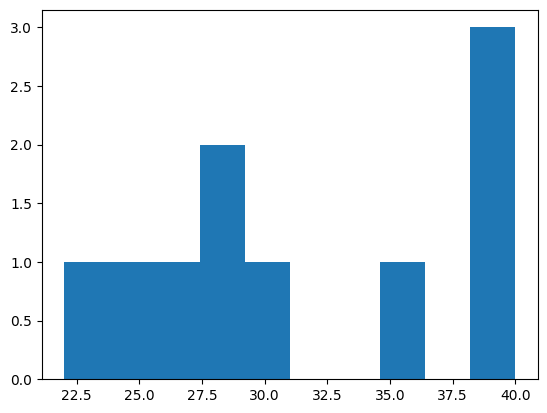

In [ ]:
plt.hist(data['Win_Age'])

In [ ]:
data['log_Age']=np.log1p(data['Age'])
data

,Name,Age,Gender,Salary,Department,Outlier,Win_Age,log_Age
0,Alice,25.000000,F,50000.000000,HR,1,25.000000,3.258097
1,Bob,30.000000,M,60000.000000,Finance,1,30.000000,3.433987
2,Charlie,39.555556,M,55000.000000,IT,1,39.555556,3.702673
3,David,40.000000,M,58000.000000,HR,1,40.000000,3.713572
4,Eve,22.000000,F,52000.000000,IT,1,22.000000,3.135494
5,Frank,35.000000,M,61000.000000,Finance,1,35.000000,3.583519
6,Grace,120.000000,F,57777.777778,Finance,-1,40.000000,4.795791
7,Henry,28.000000,M,59000.000000,HR,1,28.000000,3.367296
8,Ivy,29.000000,F,63000.000000,IT,1,29.000000,3.401197
9,Jack,27.000000,M,62000.000000,Finance,1,27.000000,3.332205


(array([2., 4., 1., 2., 0., 0., 0., 0., 0., 1.]),
 array([3.13549422, 3.30152385, 3.46755348, 3.63358311, 3.79961275,
        3.96564238, 4.13167201, 4.29770165, 4.46373128, 4.62976091,
        4.79579055]),
 <BarContainer object of 10 artists>)

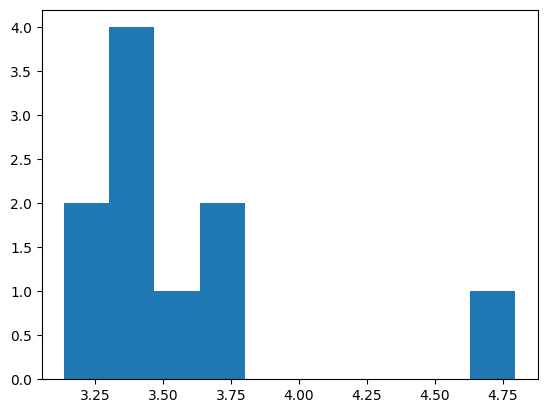

In [ ]:
plt.hist(data['log_Age'])

In [ ]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method="yeo-johnson")
data['Pow_Age']=pt.fit_transform(data[['Age']])
data

,Name,Age,Gender,Salary,Department,Outlier,Win_Age,log_Age,Pow_Age
0,Alice,25.000000,F,50000.000000,HR,1,25.000000,3.258097,-0.966514
1,Bob,30.000000,M,60000.000000,Finance,1,30.000000,3.433987,-0.100378
2,Charlie,39.555556,M,55000.000000,IT,1,39.555556,3.702673,0.784877
3,David,40.000000,M,58000.000000,HR,1,40.000000,3.713572,0.812389
4,Eve,22.000000,F,52000.000000,IT,1,22.000000,3.135494,-1.758521
5,Frank,35.000000,M,61000.000000,Finance,1,35.000000,3.583519,0.445352
6,Grace,120.000000,F,57777.777778,Finance,-1,40.000000,4.795791,1.987909
7,Henry,28.000000,M,59000.000000,HR,1,28.000000,3.367296,-0.396398
8,Ivy,29.000000,F,63000.000000,IT,1,29.000000,3.401197,-0.241400
9,Jack,27.000000,M,62000.000000,Finance,1,27.000000,3.332205,-0.567315


In [ ]:
df=data

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['En_Gender']=le.fit_transform(df[['Gender']])
df

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Name,Age,Gender,Salary,Department,Outlier,Win_Age,log_Age,Pow_Age,En_Gender
0,Alice,25.000000,F,50000.000000,HR,1,25.000000,3.258097,-0.966514,0
1,Bob,30.000000,M,60000.000000,Finance,1,30.000000,3.433987,-0.100378,1
2,Charlie,39.555556,M,55000.000000,IT,1,39.555556,3.702673,0.784877,1
3,David,40.000000,M,58000.000000,HR,1,40.000000,3.713572,0.812389,1
4,Eve,22.000000,F,52000.000000,IT,1,22.000000,3.135494,-1.758521,0
5,Frank,35.000000,M,61000.000000,Finance,1,35.000000,3.583519,0.445352,1
6,Grace,120.000000,F,57777.777778,Finance,-1,40.000000,4.795791,1.987909,0
7,Henry,28.000000,M,59000.000000,HR,1,28.000000,3.367296,-0.396398,1
8,Ivy,29.000000,F,63000.000000,IT,1,29.000000,3.401197,-0.241400,0
9,Jack,27.000000,M,62000.000000,Finance,1,27.000000,3.332205,-0.567315,1


In [ ]:
from sklearn.preprocessing import OneHotEncoder
one=OneHotEncoder(sparse_output=False)
df['Gender']=one.fit_transform(df[['Gender']])
df

,Name,Age,Gender,Salary,Department,Outlier,Win_Age,log_Age,Pow_Age,En_Gender
0,Alice,25.000000,1.0,50000.000000,HR,1,25.000000,3.258097,-0.966514,0
1,Bob,30.000000,0.0,60000.000000,Finance,1,30.000000,3.433987,-0.100378,1
2,Charlie,39.555556,0.0,55000.000000,IT,1,39.555556,3.702673,0.784877,1
3,David,40.000000,0.0,58000.000000,HR,1,40.000000,3.713572,0.812389,1
4,Eve,22.000000,1.0,52000.000000,IT,1,22.000000,3.135494,-1.758521,0
5,Frank,35.000000,0.0,61000.000000,Finance,1,35.000000,3.583519,0.445352,1
6,Grace,120.000000,1.0,57777.777778,Finance,-1,40.000000,4.795791,1.987909,0
7,Henry,28.000000,0.0,59000.000000,HR,1,28.000000,3.367296,-0.396398,1
8,Ivy,29.000000,1.0,63000.000000,IT,1,29.000000,3.401197,-0.241400,0
9,Jack,27.000000,0.0,62000.000000,Finance,1,27.000000,3.332205,-0.567315,1


In [ ]:
df=pd.get_dummies(df,columns=['Gender'],drop_first=True)
df

,Name,Age,Salary,Department,Outlier,Win_Age,log_Age,Pow_Age,En_Gender,Gender_1.0
0,Alice,25.000000,50000.000000,HR,1,25.000000,3.258097,-0.966514,0,True
1,Bob,30.000000,60000.000000,Finance,1,30.000000,3.433987,-0.100378,1,False
2,Charlie,39.555556,55000.000000,IT,1,39.555556,3.702673,0.784877,1,False
3,David,40.000000,58000.000000,HR,1,40.000000,3.713572,0.812389,1,False
4,Eve,22.000000,52000.000000,IT,1,22.000000,3.135494,-1.758521,0,True
5,Frank,35.000000,61000.000000,Finance,1,35.000000,3.583519,0.445352,1,False
6,Grace,120.000000,57777.777778,Finance,-1,40.000000,4.795791,1.987909,0,True
7,Henry,28.000000,59000.000000,HR,1,28.000000,3.367296,-0.396398,1,False
8,Ivy,29.000000,63000.000000,IT,1,29.000000,3.401197,-0.241400,0,True
9,Jack,27.000000,62000.000000,Finance,1,27.000000,3.332205,-0.567315,1,False


(array([1., 0., 1., 2., 2., 1., 2., 0., 0., 1.]),
 array([-1.75852146, -1.38387845, -1.00923544, -0.63459243, -0.25994943,
         0.11469358,  0.48933659,  0.8639796 ,  1.2386226 ,  1.61326561,
         1.98790862]),
 <BarContainer object of 10 artists>)

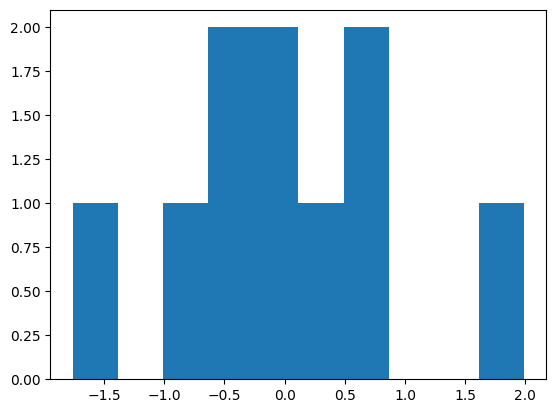

In [ ]:
plt.hist(data['Pow_Age'])

In [ ]:
pox=PowerTransformer(method="box-cox")
data['Pox_Age']=pox.fit_transform(data[['Age']])
data

,Name,Age,Gender,Salary,Department,Outlier,Win_Age,log_Age,Pow_Age,En_Gender,Pox_Age
0,Alice,25.000000,1.0,50000.000000,HR,1,25.000000,3.258097,-0.966514,0,-0.965755
1,Bob,30.000000,0.0,60000.000000,Finance,1,30.000000,3.433987,-0.100378,1,-0.098076
2,Charlie,39.555556,0.0,55000.000000,IT,1,39.555556,3.702673,0.784877,1,0.783817
3,David,40.000000,0.0,58000.000000,HR,1,40.000000,3.713572,0.812389,1,0.811174
4,Eve,22.000000,1.0,52000.000000,IT,1,22.000000,3.135494,-1.758521,0,-1.764395
5,Frank,35.000000,0.0,61000.000000,Finance,1,35.000000,3.583519,0.445352,1,0.446024
6,Grace,120.000000,1.0,57777.777778,Finance,-1,40.000000,4.795791,1.987909,0,1.985336
7,Henry,28.000000,0.0,59000.000000,HR,1,28.000000,3.367296,-0.396398,1,-0.394000
8,Ivy,29.000000,1.0,63000.000000,IT,1,29.000000,3.401197,-0.241400,0,-0.238976
9,Jack,27.000000,0.0,62000.000000,Finance,1,27.000000,3.332205,-0.567315,1,-0.565147


(array([1., 0., 1., 2., 2., 1., 2., 0., 0., 1.]),
 array([-1.76439543, -1.38942223, -1.01444904, -0.63947585, -0.26450266,
         0.11047053,  0.48544373,  0.86041692,  1.23539011,  1.6103633 ,
         1.98533649]),
 <BarContainer object of 10 artists>)

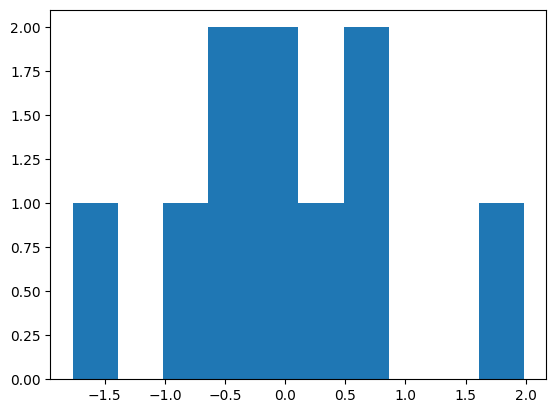

In [ ]:
plt.hist(data['Pox_Age'])

In [ ]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
st=StandardScaler()
mim=MinMaxScaler()


In [ ]:
data['Stand_Age']=st.fit_transform(data[['Age']])
data['MIM_Age']=mim.fit_transform(data[['Age']])
data

,Name,Age,Gender,Salary,Department,Outlier,Win_Age,log_Age,Pow_Age,En_Gender,Pox_Age,Stand_Age,MIM_Age
0,Alice,25.000000,1.0,50000.000000,HR,1,25.000000,3.258097,-0.966514,0,-0.965755,-0.531273,0.030612
1,Bob,30.000000,0.0,60000.000000,Finance,1,30.000000,3.433987,-0.100378,1,-0.098076,-0.348775,0.081633
2,Charlie,39.555556,0.0,55000.000000,IT,1,39.555556,3.702673,0.784877,1,0.783817,0.000000,0.179138
3,David,40.000000,0.0,58000.000000,HR,1,40.000000,3.713572,0.812389,1,0.811174,0.016222,0.183673
4,Eve,22.000000,1.0,52000.000000,IT,1,22.000000,3.135494,-1.758521,0,-1.764395,-0.640773,0.000000
5,Frank,35.000000,0.0,61000.000000,Finance,1,35.000000,3.583519,0.445352,1,0.446024,-0.166276,0.132653
6,Grace,120.000000,1.0,57777.777778,Finance,-1,40.000000,4.795791,1.987909,0,1.985336,2.936198,1.000000
7,Henry,28.000000,0.0,59000.000000,HR,1,28.000000,3.367296,-0.396398,1,-0.394000,-0.421774,0.061224
8,Ivy,29.000000,1.0,63000.000000,IT,1,29.000000,3.401197,-0.241400,0,-0.238976,-0.385275,0.071429
9,Jack,27.000000,0.0,62000.000000,Finance,1,27.000000,3.332205,-0.567315,1,-0.565147,-0.458274,0.051020


(array([6., 3., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([-0.64077251, -0.28307545,  0.07462161,  0.43231867,  0.79001572,
         1.14771278,  1.50540984,  1.86310689,  2.22080395,  2.57850101,
         2.93619806]),
 <BarContainer object of 10 artists>)

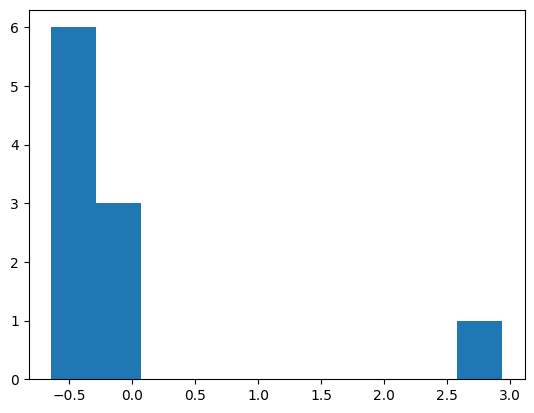

In [ ]:
plt.hist(data['Stand_Age'])

(array([6., 3., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

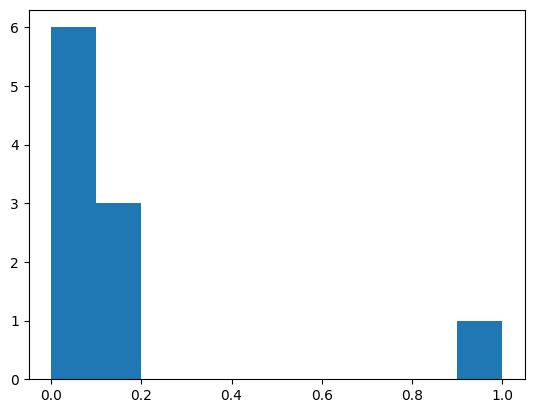

In [ ]:
plt.hist(data['MIM_Age'])